5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
              precision    recall  f1-score   support

        zero       0.87      1.00      0.93        13
         one       1.00      0.81      0.90        16
         two       1.00      1.00      1.00        16
       three       0.88      0.93      0.90        15
        four       1.00      0.56      0.71         9
        five       0.91      0.91      0.91        23
         six       1.00      0.64      0.78        11
       seven       0.73      1.00      0.84        16
       eight       0.94      0.94      0.94        16
        nine       0.89      0.96      0.92        25

    accuracy                           0.90       160
   macro avg       0.92      0.87      0.88       160
weighted avg       0.91      0.90      0.90       160



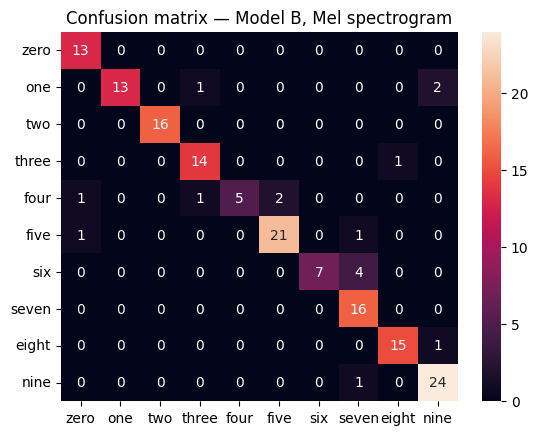

In [6]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import numpy as np
import sys
import os
sys.path.append(os.path.abspath(".."))
from config import MODEL_DIR, DATA_DIR


model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "deep_model-melSpectrogram.keras"))

digits = ['zero','one','two','three','four','five','six','seven','eight','nine']

# Last inn testdata
X_test_mel = np.load(os.path.join(DATA_DIR, "X_test_mel.npy"))
y_test = np.load(os.path.join(DATA_DIR, "y_test.npy"))

# Lag TensorFlow dataset
test_ds = tf.data.Dataset.from_tensor_slices((X_test_mel, y_test)).batch(32)

y_pred = model.predict(test_ds).argmax(axis=1)
y_true = [label for _, label in test_ds.unbatch()]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=digits, yticklabels=digits)
plt.title("Confusion matrix — Model B, Mel spectrogram")
plt.savefig("confusion_matrix.png")

# Per-class metrics
print(classification_report(y_true, y_pred, target_names=digits))